### CONCLUSION: DON'T NEED SOFTWARE CALIBRATION, ONLY MAKE SOME CASES WORSE AND SOME CASES BETTER, CANNOT MAKE IT BETTER IN GENERAL, MODE_HIGH_QUALITY ALREADY TOO GOOD

In [279]:
yuv_video_path = '/home/filelele/personal_project/autonomous-rover/src/Phone/camera_calibrate/recording_20260917_220320.yuv'
frames_folder = '/home/filelele/personal_project/autonomous-rover/src/Phone/camera_calibrate/capture01/'
width = 640
height = 480

# chessboard properties
columns = 11
rows = 8
grid_size = 1

# calibration properties
eps = 0.001
max_iter = 30
single_square_estimate_fraction_of_w = 0.05
search_window_half_w = max(round(width * single_square_estimate_fraction_of_w / 4) , 3)

In [280]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
import glob
import os

In [300]:
images = sorted(glob.glob(frames_folder + '*.jpg'))
images = [images[i] for i in range(0,len(images),1)]
len(images)

28

(480, 640, 3)


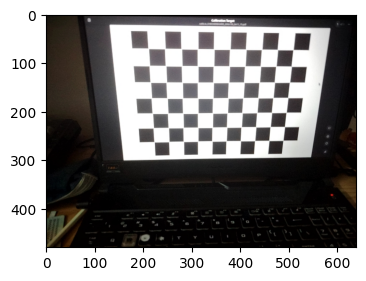

In [301]:
test_img = cv.imread(images[-1])
print(test_img.shape)
plt.figure(figsize=(4,6))
plt.imshow(cv.cvtColor(test_img, cv.COLOR_BGR2RGB))

In [302]:
object_points_matrix = np.zeros(((columns - 1)*(rows - 1),3), np.float32)
object_points_matrix[:,:2] = np.mgrid[0:(columns-1), 0:(rows-1)].T.reshape(-1,2) * grid_size

In [284]:
object_points_matrix

array([[0., 0., 0.],
       [1., 0., 0.],
       [2., 0., 0.],
       [3., 0., 0.],
       [4., 0., 0.],
       [5., 0., 0.],
       [6., 0., 0.],
       [7., 0., 0.],
       [8., 0., 0.],
       [9., 0., 0.],
       [0., 1., 0.],
       [1., 1., 0.],
       [2., 1., 0.],
       [3., 1., 0.],
       [4., 1., 0.],
       [5., 1., 0.],
       [6., 1., 0.],
       [7., 1., 0.],
       [8., 1., 0.],
       [9., 1., 0.],
       [0., 2., 0.],
       [1., 2., 0.],
       [2., 2., 0.],
       [3., 2., 0.],
       [4., 2., 0.],
       [5., 2., 0.],
       [6., 2., 0.],
       [7., 2., 0.],
       [8., 2., 0.],
       [9., 2., 0.],
       [0., 3., 0.],
       [1., 3., 0.],
       [2., 3., 0.],
       [3., 3., 0.],
       [4., 3., 0.],
       [5., 3., 0.],
       [6., 3., 0.],
       [7., 3., 0.],
       [8., 3., 0.],
       [9., 3., 0.],
       [0., 4., 0.],
       [1., 4., 0.],
       [2., 4., 0.],
       [3., 4., 0.],
       [4., 4., 0.],
       [5., 4., 0.],
       [6., 4., 0.],
       [7., 4

In [286]:
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 60, 0.0001)

In [303]:
object_points = []
image_points = []
corners_not_found_images = []
for image in images:
    img = cv.imread(image)
    if img is None:
        print(f"Failed to load image: {image}")
        break
    """
    plt.figure(figsize=(10, 8))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    """
    print(f"Processing image: {image}")
    print(f"Image shape: {img.shape}")
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    ret, corners = cv.findChessboardCorners(gray, ((columns - 1),(rows - 1)), None)
    print(f"Chessboard corners found: {ret}, number of corners: {corners.shape[0] if ret else 0}")
    if ret == True:
        object_points.append(object_points_matrix)
        corners2 = cv.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
        image_points.append(corners2)
        img = cv.drawChessboardCorners(img, ((columns - 1),(rows - 1)), corners2, ret)
        
        print(img.shape, img.dtype, img.max(), img.min())
        """
        plt.figure(figsize=(6, 4))
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
        """
    else :
        print(f"Chessboard corners not found in image: {image}")
        corners_not_found_images.append(image)
# cv.destroyAllWindows()

Processing image: /home/filelele/personal_project/autonomous-rover/src/Phone/camera_calibrate/capture01/capture_20260918_003418_074.jpg
Image shape: (480, 640, 3)
Chessboard corners found: True, number of corners: 70
(480, 640, 3) uint8 255 0
Processing image: /home/filelele/personal_project/autonomous-rover/src/Phone/camera_calibrate/capture01/capture_20260918_003420_341.jpg
Image shape: (480, 640, 3)
Chessboard corners found: True, number of corners: 70
(480, 640, 3) uint8 255 0
Processing image: /home/filelele/personal_project/autonomous-rover/src/Phone/camera_calibrate/capture01/capture_20260918_003423_495.jpg
Image shape: (480, 640, 3)
Chessboard corners found: True, number of corners: 70
(480, 640, 3) uint8 255 0
Processing image: /home/filelele/personal_project/autonomous-rover/src/Phone/camera_calibrate/capture01/capture_20260918_003426_720.jpg
Image shape: (480, 640, 3)
Chessboard corners found: True, number of corners: 70
(480, 640, 3) uint8 255 0
Processing image: /home/file

In [304]:
len(corners_not_found_images), len(images), len(object_points), len(image_points)

(0, 28, 28, 28)

In [305]:
corners_not_found_images

[]

Frame dimensions : 640 x 480
X coverage range : [23.4 to 609.9] -> Uncovered left: 23.4px, right: 30.1px
Y coverage range : [10.7 to 453.4] -> Uncovered top: 10.7px, bottom: 26.6px


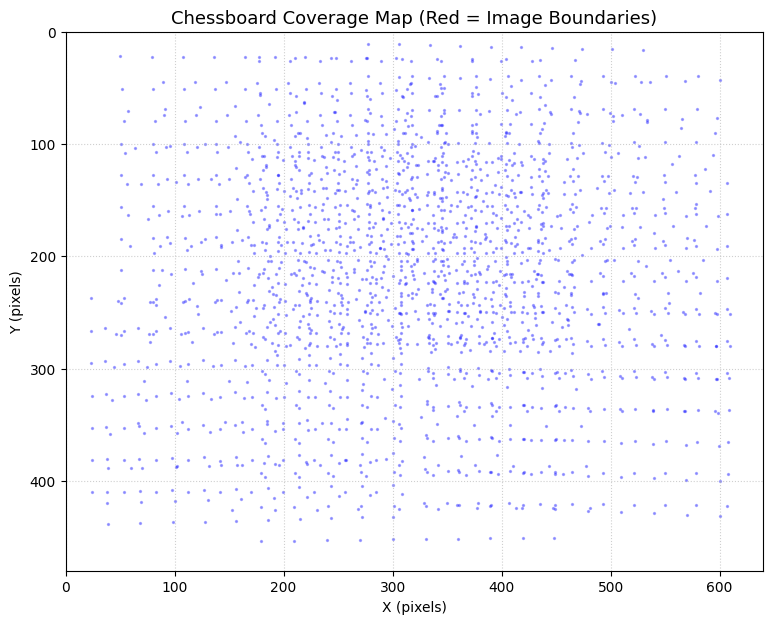

In [306]:
# --- Calibration Samples Coverage ---

# Flatten all detected image points across all calibration frames
all_pts = np.vstack(image_points).reshape(-1, 2)
min_x, max_x = np.min(all_pts[:, 0]), np.max(all_pts[:, 0])
min_y, max_y = np.min(all_pts[:, 1]), np.max(all_pts[:, 1])
print(f"Frame dimensions : {width} x {height}")
print(f"X coverage range : [{min_x:.1f} to {max_x:.1f}] -> Uncovered left: {min_x:.1f}px, right: {width - max_x:.1f}px")
print(f"Y coverage range : [{min_y:.1f} to {max_y:.1f}] -> Uncovered top: {min_y:.1f}px, bottom: {height - max_y:.1f}px")
plt.figure(figsize=(9, round(9*(height/width))) )
# 2D histogram / scatter plot of all corners
plt.scatter(all_pts[:, 0], all_pts[:, 1], s=2, alpha=0.3, color='blue')
plt.xlim(0, width)
plt.ylim(height, 0)  # Invert Y to match image coordinates

plt.title("Chessboard Coverage Map (Red = Image Boundaries)", fontsize=13)
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


In [313]:
ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(object_points, image_points, gray.shape[::-1], None, None, flags=cv.CALIB_FIX_K3 | cv.CALIB_FIX_K2)

In [314]:
mtx

array([[439.01843131,   0.        , 317.97865445],
       [  0.        , 438.70003169, 241.46409186],
       [  0.        ,   0.        ,   1.        ]])

In [315]:
ret

0.287412902818259

In [316]:
dist

array([[ 0.00497214,  0.        , -0.00029388, -0.00010055,  0.        ]])

### Distortion correction on some samples and 
### Straightness of CHESSBOARD CORNERS ONLY improvement report

In [317]:
import random
sample_indices = random.sample(range(len(images)), k=22)
sample_images = [images[i] for i in sample_indices]
sample_indices

# sample_indices = [0, len(images) // 2, -1]
# sample_images = [images[i] for i in sample_indices]


[16, 11, 10, 4, 0, 17, 15, 14, 12, 27, 5, 2, 13, 7, 22, 1, 24, 9, 20, 21, 3, 8]

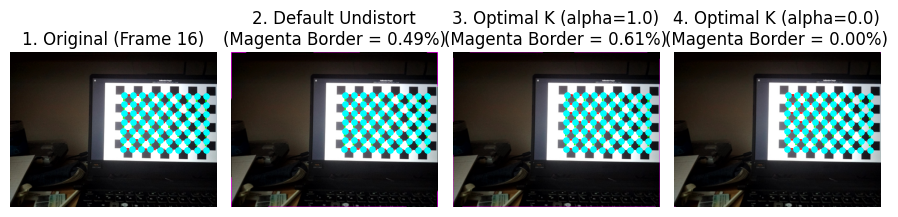

============================ Frame #16 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.0882 px   | 0.0594 px   | 0.0738 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.0946 px   | 0.0638 px   | 0.0792 px   | -7.3%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.0948 px   | 0.0640 px   | 0.0794 px   | -7.5%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.0950 px   | 0.0641 px   | 0.0796 px   | -7.8%



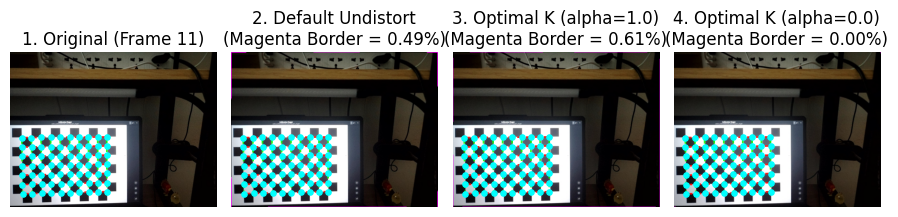

============================ Frame #11 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.0829 px   | 0.0570 px   | 0.0700 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.0927 px   | 0.0657 px   | 0.0792 px   | -13.2%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.0928 px   | 0.0659 px   | 0.0793 px   | -13.4%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.0931 px   | 0.0660 px   | 0.0795 px   | -13.7%



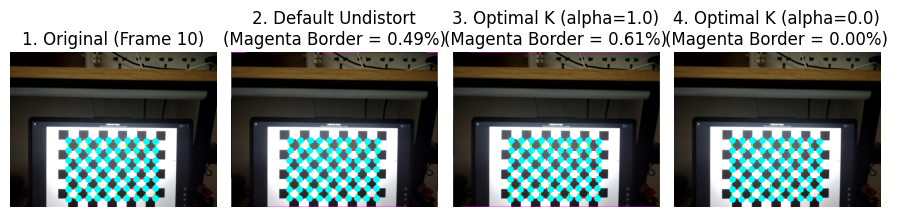

============================ Frame #10 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.1353 px   | 0.0688 px   | 0.1021 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.1287 px   | 0.0729 px   | 0.1008 px   | +1.2%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.1289 px   | 0.0731 px   | 0.1010 px   | +1.0%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.1293 px   | 0.0733 px   | 0.1013 px   | +0.8%



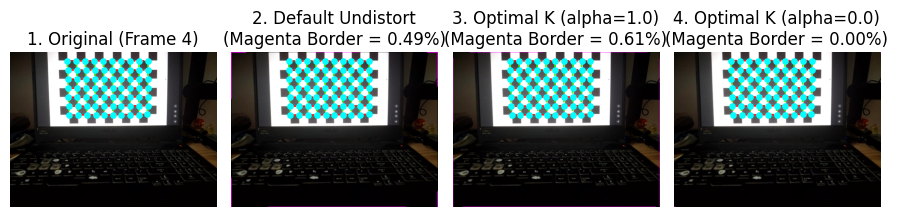

============================ Frame #4 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.1293 px   | 0.0625 px   | 0.0959 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.1113 px   | 0.0657 px   | 0.0885 px   | +7.7%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.1114 px   | 0.0659 px   | 0.0887 px   | +7.5%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.1118 px   | 0.0660 px   | 0.0889 px   | +7.3%



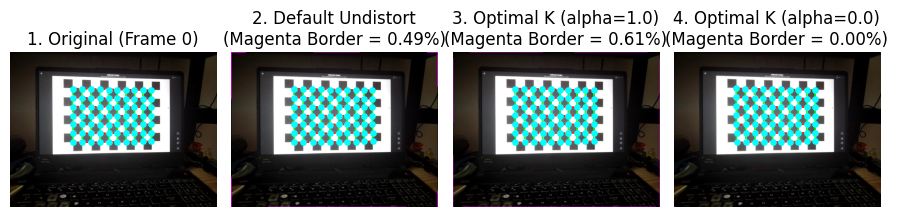

============================ Frame #0 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.1471 px   | 0.0667 px   | 0.1069 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.1395 px   | 0.0637 px   | 0.1016 px   | +5.0%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.1397 px   | 0.0638 px   | 0.1018 px   | +4.8%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.1401 px   | 0.0640 px   | 0.1020 px   | +4.6%



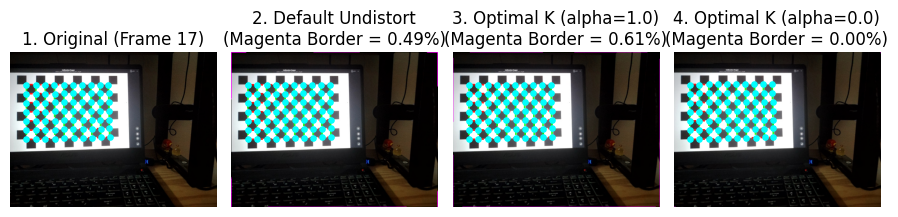

============================ Frame #17 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.0713 px   | 0.0390 px   | 0.0552 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.0810 px   | 0.0428 px   | 0.0619 px   | -12.2%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.0811 px   | 0.0429 px   | 0.0620 px   | -12.4%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.0813 px   | 0.0430 px   | 0.0622 px   | -12.7%



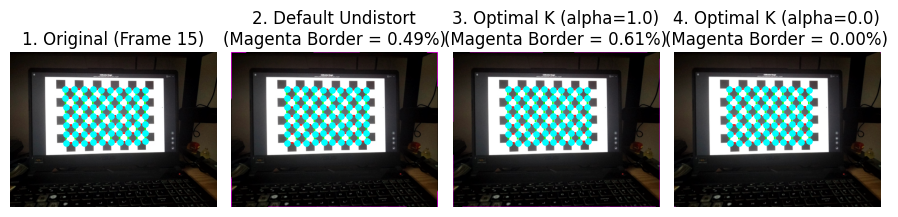

============================ Frame #15 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.1343 px   | 0.0801 px   | 0.1072 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.1263 px   | 0.0775 px   | 0.1019 px   | +4.9%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.1265 px   | 0.0777 px   | 0.1021 px   | +4.8%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.1268 px   | 0.0778 px   | 0.1023 px   | +4.5%



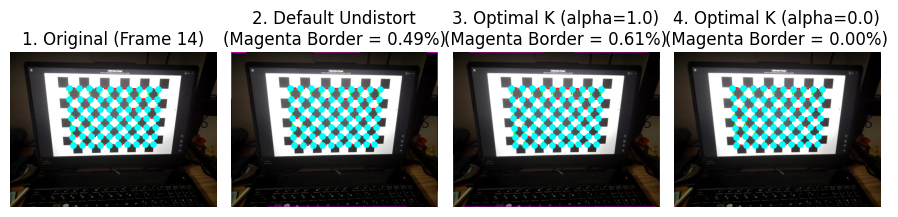

============================ Frame #14 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.1482 px   | 0.0682 px   | 0.1082 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.1389 px   | 0.0652 px   | 0.1021 px   | +5.6%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.1391 px   | 0.0654 px   | 0.1023 px   | +5.5%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.1395 px   | 0.0655 px   | 0.1025 px   | +5.2%



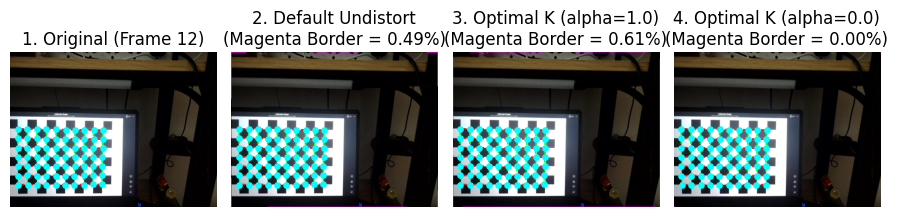

============================ Frame #12 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.0721 px   | 0.0539 px   | 0.0630 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.0798 px   | 0.0620 px   | 0.0709 px   | -12.5%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.0799 px   | 0.0622 px   | 0.0710 px   | -12.7%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.0801 px   | 0.0623 px   | 0.0712 px   | -13.0%



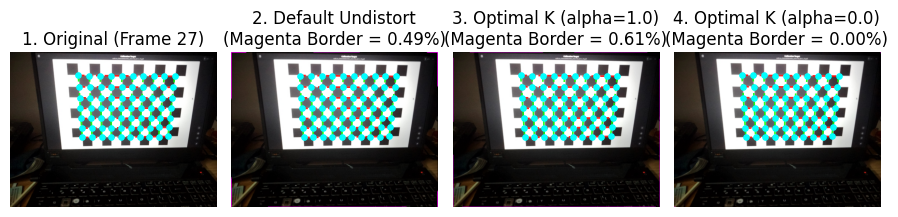

============================ Frame #27 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.1106 px   | 0.0579 px   | 0.0843 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.0978 px   | 0.0600 px   | 0.0789 px   | +6.4%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.0979 px   | 0.0601 px   | 0.0790 px   | +6.2%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.0982 px   | 0.0603 px   | 0.0792 px   | +6.0%



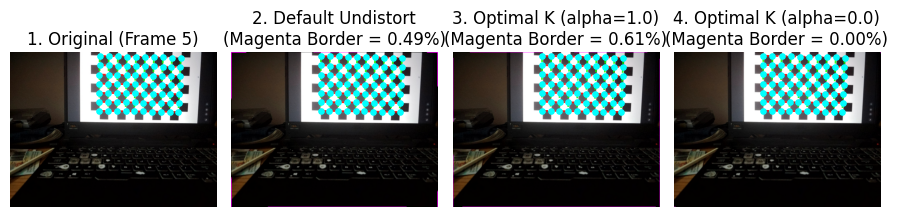

============================ Frame #5 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.0629 px   | 0.0740 px   | 0.0684 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.0661 px   | 0.0786 px   | 0.0723 px   | -5.7%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.0662 px   | 0.0788 px   | 0.0725 px   | -5.9%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.0664 px   | 0.0789 px   | 0.0727 px   | -6.2%



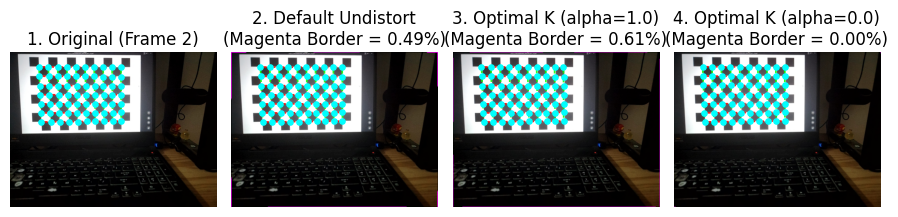

============================ Frame #2 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.0585 px   | 0.0581 px   | 0.0583 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.0652 px   | 0.0631 px   | 0.0641 px   | -10.0%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.0653 px   | 0.0633 px   | 0.0643 px   | -10.2%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.0655 px   | 0.0634 px   | 0.0644 px   | -10.5%



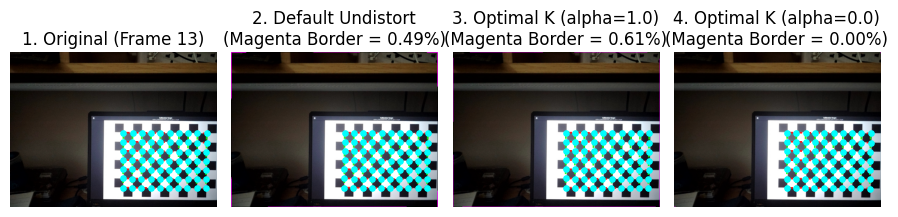

============================ Frame #13 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.0796 px   | 0.0574 px   | 0.0685 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.0869 px   | 0.0659 px   | 0.0764 px   | -11.5%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.0870 px   | 0.0661 px   | 0.0765 px   | -11.7%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.0872 px   | 0.0662 px   | 0.0767 px   | -12.0%



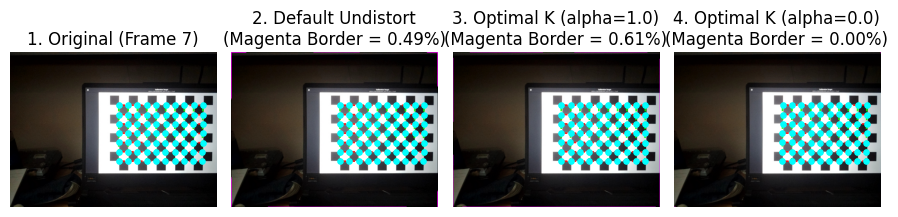

============================ Frame #7 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.0903 px   | 0.0617 px   | 0.0760 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.0967 px   | 0.0620 px   | 0.0793 px   | -4.4%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.0969 px   | 0.0621 px   | 0.0795 px   | -4.6%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.0971 px   | 0.0622 px   | 0.0797 px   | -4.9%



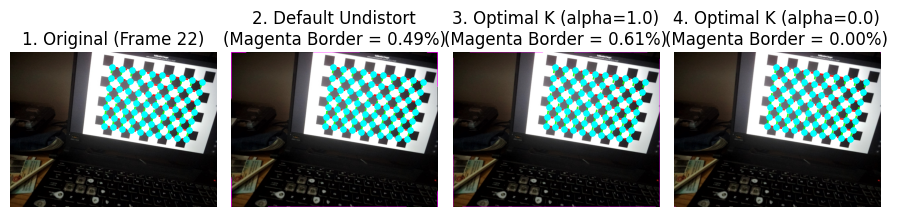

============================ Frame #22 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.0707 px   | 0.0595 px   | 0.0651 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.0809 px   | 0.0644 px   | 0.0727 px   | -11.7%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.0811 px   | 0.0646 px   | 0.0728 px   | -11.9%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.0813 px   | 0.0647 px   | 0.0730 px   | -12.2%



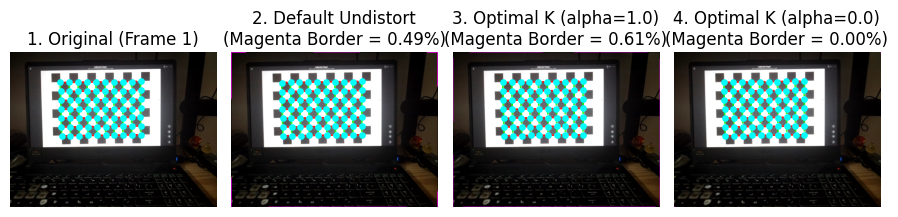

============================ Frame #1 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.1161 px   | 0.0568 px   | 0.0865 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.1067 px   | 0.0569 px   | 0.0818 px   | +5.4%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.1069 px   | 0.0570 px   | 0.0820 px   | +5.2%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.1072 px   | 0.0571 px   | 0.0822 px   | +5.0%



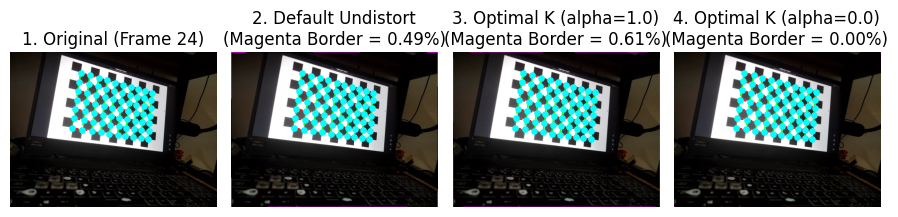

============================ Frame #24 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.1416 px   | 0.0424 px   | 0.0920 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.1324 px   | 0.0410 px   | 0.0867 px   | +5.8%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.1327 px   | 0.0411 px   | 0.0869 px   | +5.6%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.1330 px   | 0.0412 px   | 0.0871 px   | +5.3%



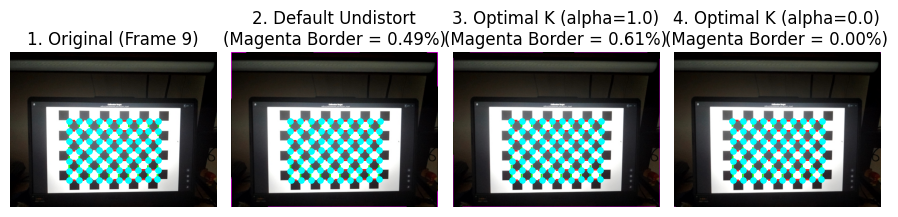

============================ Frame #9 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.1439 px   | 0.0637 px   | 0.1038 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.1362 px   | 0.0616 px   | 0.0989 px   | +4.7%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.1364 px   | 0.0618 px   | 0.0991 px   | +4.5%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.1368 px   | 0.0619 px   | 0.0993 px   | +4.3%



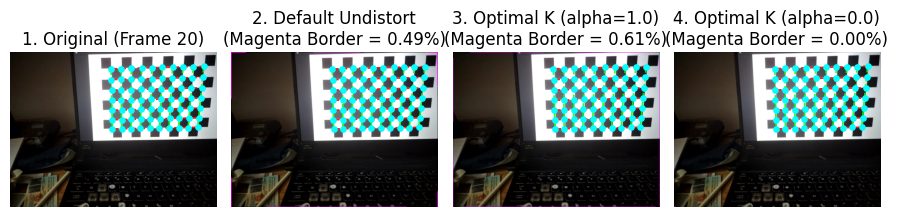

============================ Frame #20 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.0823 px   | 0.0603 px   | 0.0713 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.0990 px   | 0.0652 px   | 0.0821 px   | -15.1%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.0991 px   | 0.0653 px   | 0.0822 px   | -15.3%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.0994 px   | 0.0654 px   | 0.0824 px   | -15.6%



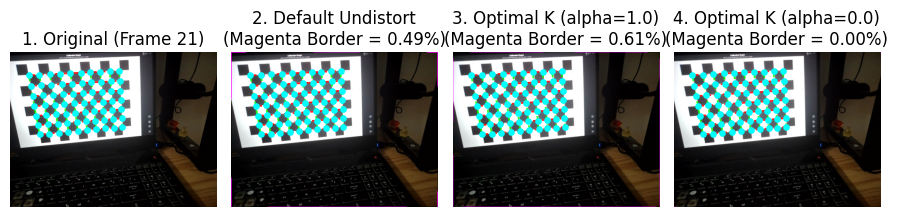

============================ Frame #21 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.0716 px   | 0.0418 px   | 0.0567 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.0821 px   | 0.0466 px   | 0.0643 px   | -13.4%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.0822 px   | 0.0467 px   | 0.0644 px   | -13.7%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.0824 px   | 0.0468 px   | 0.0646 px   | -13.9%



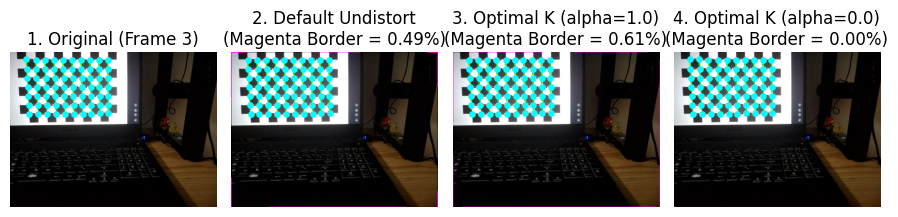

============================ Frame #3 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.0719 px   | 0.0665 px   | 0.0692 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.0854 px   | 0.0698 px   | 0.0776 px   | -12.2%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.0855 px   | 0.0700 px   | 0.0777 px   | -12.4%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.0857 px   | 0.0701 px   | 0.0779 px   | -12.7%



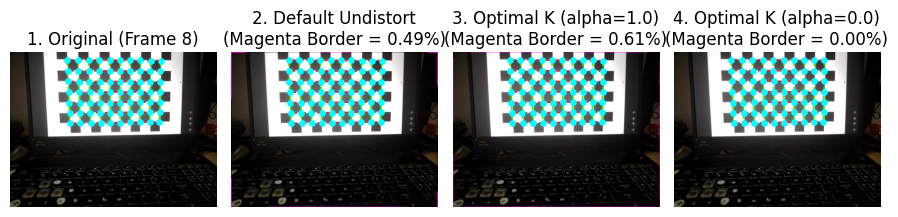

============================ Frame #8 Straightness Report ============================
Mode                   | Border %   | Horiz Mean   | Vert Mean    | Total Mean   | Improvement
--------------------------------------------------------------------------------------------
Original               | 0.00%      | 0.1274 px   | 0.0690 px   | 0.0982 px   | Baseline
Default (K=mtx)        |  0.49%    | 0.1116 px   | 0.0745 px   | 0.0930 px   | +5.3%
alpha=1.0 (Zoom Out)   |  0.61%    | 0.1117 px   | 0.0747 px   | 0.0932 px   | +5.1%
alpha=0.0 (Auto-Crop)  |  0.00%    | 0.1120 px   | 0.0748 px   | 0.0934 px   | +4.9%



In [318]:
c_count = columns - 1  
r_count = rows - 1     

h, w = cv.imread(sample_images[0]).shape[:2]
# 1. Compute optimal camera matrices
new_mtx_alpha1, roi_alpha1 = cv.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1.0, (w, h))
new_mtx_alpha0, roi_alpha0 = cv.getOptimalNewCameraMatrix(mtx, dist, (w, h), 0.0, (w, h))
# 2. Precompute rectification maps
map1_default, map2_default = cv.initUndistortRectifyMap(mtx, dist, None, mtx, (w, h), cv.CV_16SC2)
map1_alpha1,  map2_alpha1  = cv.initUndistortRectifyMap(mtx, dist, None, new_mtx_alpha1, (w, h), cv.CV_16SC2)
map1_alpha0,  map2_alpha0  = cv.initUndistortRectifyMap(mtx, dist, None, new_mtx_alpha0, (w, h), cv.CV_16SC2)
# 3. Create white mask to isolate out-of-bounds border pixels for ALL three modes
ones_mask = np.full((h, w), 255, dtype=np.uint8)
border_mask_default = cv.remap(ones_mask, map1_default, map2_default, cv.INTER_NEAREST, borderMode=cv.BORDER_CONSTANT, borderValue=0) == 0
border_mask_alpha1  = cv.remap(ones_mask, map1_alpha1,  map2_alpha1,  cv.INTER_NEAREST, borderMode=cv.BORDER_CONSTANT, borderValue=0) == 0
border_mask_alpha0  = cv.remap(ones_mask, map1_alpha0,  map2_alpha0,  cv.INTER_NEAREST, borderMode=cv.BORDER_CONSTANT, borderValue=0) == 0
pct_border_default = (np.sum(border_mask_default) / (w * h)) * 100.0
pct_border_alpha1  = (np.sum(border_mask_alpha1)  / (w * h)) * 100.0
pct_border_alpha0  = (np.sum(border_mask_alpha0)  / (w * h)) * 100.0
# Helper: Orthogonal distance from points to best-fit straight line
def line_residuals(pts):
    mean = np.mean(pts, axis=0)
    _, _, vv = np.linalg.svd(pts - mean)
    normal = vv[1]
    return np.abs(np.dot(pts - mean, normal))
def evaluate_grid_straightness(pts, cols, rws):
    h_errs, v_errs = [], []
    for r in range(rws):
        h_errs.extend(line_residuals(pts[r * cols : (r + 1) * cols]))
    for c in range(cols):
        v_errs.extend(line_residuals(pts[c :: cols]))
    all_errs = h_errs + v_errs
    return np.mean(h_errs), np.mean(v_errs), np.mean(all_errs), np.max(all_errs)
# Helper: Draw grid lines and corner dots on an axis
def draw_grid_overlay(ax, pts, cols, rws):
    if pts is None:
        return
    # Horizontal lines (Red dashed)
    for r in range(rws):
        row = pts[r * cols : (r + 1) * cols]
        ax.plot([row[0, 0], row[-1, 0]], [row[0, 1], row[-1, 1]], 'r--', linewidth=1.2, alpha=0.85, zorder=2)
    # Vertical lines (Lime dashed)
    for c in range(cols):
        col = pts[c :: cols]
        ax.plot([col[0, 0], col[-1, 0]], [col[0, 1], col[-1, 1]], color='lime', linestyle='--', linewidth=1.2, alpha=0.85, zorder=2)
    # Corner dots (Cyan)
    ax.scatter(pts[:, 0], pts[:, 1], color='cyan', s=14, zorder=3)
# Process each sample image
for idx, img_path in enumerate(sample_images):
    img = cv.imread(img_path)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    # 1. Remap images
    undist_default = cv.remap(img_rgb, map1_default, map2_default, cv.INTER_LINEAR)
    undist_alpha1  = cv.remap(img_rgb, map1_alpha1,  map2_alpha1,  cv.INTER_LINEAR)
    undist_alpha0  = cv.remap(img_rgb, map1_alpha0,  map2_alpha0,  cv.INTER_LINEAR)
    # 2. Apply magenta highlight to ALL THREE undistorted images
    view_default = undist_default.copy()
    view_default[border_mask_default] = [255, 0, 255]
    view_alpha1 = undist_alpha1.copy()
    view_alpha1[border_mask_alpha1] = [255, 0, 255]
    view_alpha0 = undist_alpha0.copy()
    view_alpha0[border_mask_alpha0] = [255, 0, 255]
    # 3. Detect corners and compute straightness
    found, corners = cv.findChessboardCorners(gray, (c_count, r_count), None)
    pts_orig, pts_default, pts_alpha1, pts_alpha0 = None, None, None, None
    if found:
        pts_orig = cv.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria).reshape(-1, 2)
        
        # Project undistorted points into each virtual camera space
        pts_default = cv.undistortPoints(pts_orig.reshape(-1, 1, 2), mtx, dist, P=mtx).reshape(-1, 2)
        pts_alpha1  = cv.undistortPoints(pts_orig.reshape(-1, 1, 2), mtx, dist, P=new_mtx_alpha1).reshape(-1, 2)
        pts_alpha0  = cv.undistortPoints(pts_orig.reshape(-1, 1, 2), mtx, dist, P=new_mtx_alpha0).reshape(-1, 2)
        # Compute straightness errors (h_mean, v_mean, total_mean, max_err)
        orig_err    = evaluate_grid_straightness(pts_orig, c_count, r_count)
        default_err = evaluate_grid_straightness(pts_default, c_count, r_count)
        alpha1_err  = evaluate_grid_straightness(pts_alpha1, c_count, r_count)
        alpha0_err  = evaluate_grid_straightness(pts_alpha0, c_count, r_count)
    # 4. Render 2x2 Subplots
    fig, axes = plt.subplots(1, 4, figsize=(9, 9*round(height/width)))
    axes = axes.flatten()
    # Original
    axes[0].imshow(img_rgb)
    draw_grid_overlay(axes[0], pts_orig, c_count, r_count)
    axes[0].set_title(f"1. Original (Frame {sample_indices[idx]})", fontsize=12)
    axes[0].axis('off')
    # Default
    axes[1].imshow(view_default)
    draw_grid_overlay(axes[1], pts_default, c_count, r_count)
    axes[1].set_title(f"2. Default Undistort\n(Magenta Border = {pct_border_default:.2f}%)", fontsize=12)
    axes[1].axis('off')
    # Alpha = 1.0
    axes[2].imshow(view_alpha1)
    draw_grid_overlay(axes[2], pts_alpha1, c_count, r_count)
    axes[2].set_title(f"3. Optimal K (alpha=1.0)\n(Magenta Border = {pct_border_alpha1:.2f}%)", fontsize=12)
    axes[2].axis('off')
    # Alpha = 0.0
    axes[3].imshow(view_alpha0)
    draw_grid_overlay(axes[3], pts_alpha0, c_count, r_count)
    axes[3].set_title(f"4. Optimal K (alpha=0.0)\n(Magenta Border = {pct_border_alpha0:.2f}%)", fontsize=12)
    axes[3].axis('off')
    plt.tight_layout()
    plt.show()
    # 5. Print Straightness Report for this frame
    print(f"============================ Frame #{sample_indices[idx]} Straightness Report ============================")
    if found:
        print(f"{'Mode':<22} | {'Border %':<10} | {'Horiz Mean':<12} | {'Vert Mean':<12} | {'Total Mean':<12} | {'Improvement'}")
        print("-" * 92)
        print(f"{'Original':<22} | {'0.00%':<10} | {orig_err[0]:.4f} px   | {orig_err[1]:.4f} px   | {orig_err[2]:.4f} px   | Baseline")
        
        for name, pct, err in [
            ("Default (K=mtx)", pct_border_default, default_err),
            ("alpha=1.0 (Zoom Out)", pct_border_alpha1, alpha1_err),
            ("alpha=0.0 (Auto-Crop)", pct_border_alpha0, alpha0_err)
        ]:
            imp = (1.0 - err[2] / orig_err[2]) * 100.0
            imp_str = f"+{imp:.1f}%" if imp >= 0 else f"{imp:.1f}%"
            print(f"{name:<22} | {pct:>5.2f}%    | {err[0]:.4f} px   | {err[1]:.4f} px   | {err[2]:.4f} px   | {imp_str}")
    else:
        print("Chessboard corners not detected in this frame to compute straightness metrics.")
    print("========================================================================================\n")


In [297]:
# --- Find which frames are causing high reprojection error ---
import numpy as np

frame_errors = []

for i in range(len(object_points)):
    # Project 3D object points to 2D image coordinates
    projected_points, _ = cv.projectPoints(object_points[i], rvecs[i], tvecs[i], mtx, dist)
    
    # Reshape both to clean (N, 2) arrays
    pts_actual = np.array(image_points[i], dtype=np.float32).reshape(-1, 2)
    pts_proj = np.array(projected_points, dtype=np.float32).reshape(-1, 2)
    
    # Calculate Euclidean Root Mean Square Error (RMSE) in pixels
    error = np.sqrt(np.mean(np.sum((pts_actual - pts_proj)**2, axis=1)))
    frame_errors.append((i, error))

# Sort from worst to best
frame_errors.sort(key=lambda x: x[1], reverse=True)

print(f"Overall RMS error (ret): {ret:.4f} pixels\n")
print(f"{'Rank':<6} | {'Frame Index':<12} | {'RMS Error (px)':<15} | {'Status'}")
print("-" * 55)

for rank, (frame_idx, err) in enumerate(frame_errors):
    status = "OUTLIER (Consider dropping)" if err > 0.8 else "Good"
    print(f"#{rank+1:<5} | Frame {frame_idx:<6} | {err:.4f} px        | {status}")


Overall RMS error (ret): 0.2201 pixels

Rank   | Frame Index  | RMS Error (px)  | Status
-------------------------------------------------------
#1     | Frame 29     | 0.2865 px        | Good
#2     | Frame 21     | 0.2709 px        | Good
#3     | Frame 27     | 0.2639 px        | Good
#4     | Frame 4      | 0.2593 px        | Good
#5     | Frame 16     | 0.2482 px        | Good
#6     | Frame 1      | 0.2402 px        | Good
#7     | Frame 15     | 0.2339 px        | Good
#8     | Frame 10     | 0.2325 px        | Good
#9     | Frame 13     | 0.2292 px        | Good
#10    | Frame 20     | 0.2241 px        | Good
#11    | Frame 12     | 0.2218 px        | Good
#12    | Frame 14     | 0.2216 px        | Good
#13    | Frame 28     | 0.2201 px        | Good
#14    | Frame 0      | 0.2165 px        | Good
#15    | Frame 24     | 0.2098 px        | Good
#16    | Frame 26     | 0.2093 px        | Good
#17    | Frame 7      | 0.2085 px        | Good
#18    | Frame 8      | 0.2077 px      

In [299]:
images[26]

'/home/filelele/personal_project/autonomous-rover/src/Phone/camera_calibrate/capture01/capture_20260918_003606_368.jpg'